### Refinement of Malignant T Cell Clones (Figure S7)

**Manuscript Context:** This notebook contains the code and workflows used to generate Figure S7 for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to investigate the proliferative capacity and clonal dynamics of proliferating T cells subpopulations. Specifically, we:
1.  Visualize the genomic landscape of proliferation by projecting CNV status and clonal_size metrics onto the Tprol UMAP space.
2.  Quantify clonal expansion by generating a bar plot depicting the number of cells per TCR clone (airr:clone_id) within the refined T12 Malig_MKI67 and T12-Tprol_MKI67 subpopulations.
3.  Conduct a comparative genomic analysis using CNV heatmaps to display genome-wide log2 fold change (LFC) signals for Tprol cells, as well as a comparison between malignant T and NK cells, utilizing normal NK cells as a reference.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import muon as mu
import scirpy as ir
import matplotlib as mpl
import matplotlib.ticker as ticker
import sys
import os
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [ ]:
figPath = "./figures/figS3"
TprolPath = './data/NKTCL_Tprol.h5ad'
NKPath = './data/NKTCL_NK.h5ad'
TPath = './data/NKTCL_T.h5ad'
irPath = './data/NKTCL-ir.h5ad'
datPath = "./data/NKTCL_concat.h5ad"
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_Tprol = sc.read_h5ad(TprolPath)
adata_concat = sc.read_h5ad(datPath)
adata_NK = sc.read_h5ad(NKPath)
nktcl_ir = sc.read_h5ad(irPath)
adata_T = sc.read_h5ad(TPath)

#### **Fig. S7a** CNV UMAP projection of proliferating T cells (Tprol) colored by CNV status

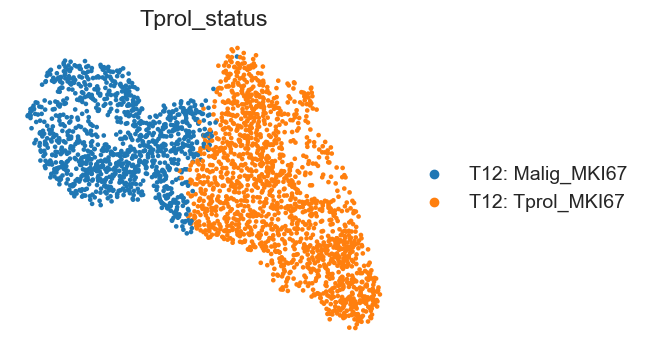

In [950]:
import infercnvpy as cnv 
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cnv.pl.umap(adata_Tprol, color=['Tprol_status'], ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/FigS7a.png", dpi=150, bbox_inches='tight')

#### **Fig. S7b** CNV UMAP projection of proliferating T cells (Tprol) colored by clonal size

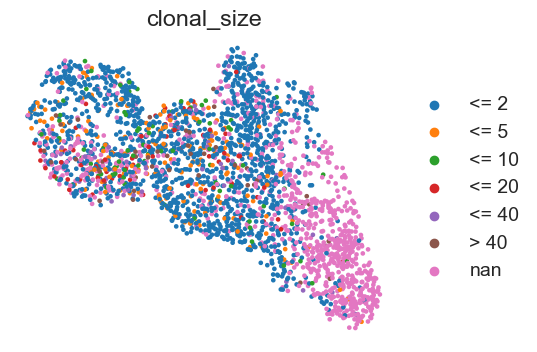

In [951]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cnv.pl.umap(adata_Tprol, color=['clonal_size'], ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/FigS7b.png", dpi=150, bbox_inches='tight')

#### **Fig. S7c** CNV heatmap of Tprol cells, displaying genome-wide log2 fold change (LFC) signals (red = am-plification, blue = deletion) relative to normal NK cell references.

In [ ]:
mdata_Tprol = mu.MuData({'gex': adata_Tprol, "airr":nktcl_ir})
ir.pp.index_chains(mdata_Tprol)
ir.tl.chain_qc(mdata_Tprol)
ir.pp.ir_dist(mdata_Tprol, metric="identity", sequence="aa", key_added="ir_dist_aa_identity", n_jobs=16)
ir.tl.define_clonotypes(mdata_Tprol, key_added="clone_id", same_v_gene=False, dual_ir='primary_only',receptor_arms="all" )
ir.tl.clonal_expansion(mdata_Tprol, target_col="clone_id", key_added="clonal_expansion", breakpoints=[2,5,10,20])

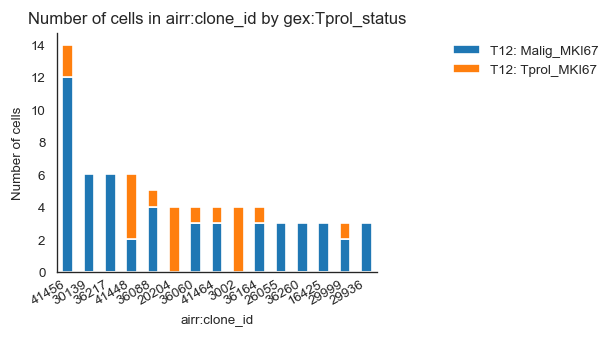

In [952]:
ir.pl.group_abundance(mdata_Tprol, groupby='airr:clone_id', target_col='gex:Tprol_status', max_cols=15).figure.savefig(f'{figPath}/FigS7c.pdf', bbox_inches='tight')

#### **Fig. S7d** CNV heatmap of Tprol cells, displaying genome-wide log2 fold change (LFC) signals (red = am-plification, blue = deletion) relative to normal NK cell references.

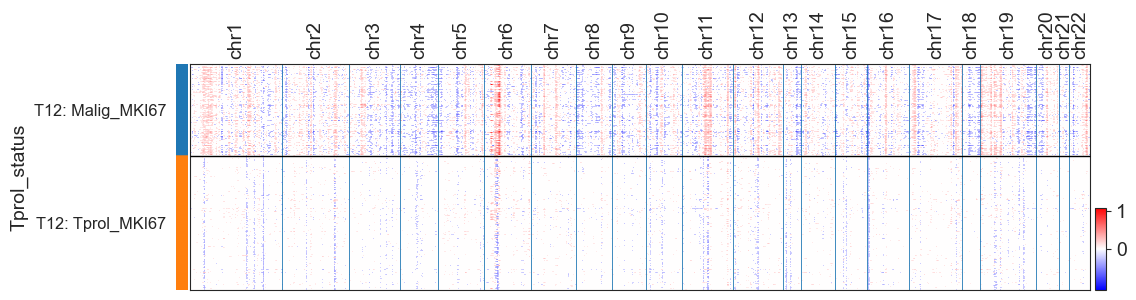

In [948]:
ax = cnv.pl.chromosome_heatmap(adata_Tprol, groupby='Tprol_status',show = False)
fig = ax['heatmap_ax'].get_figure()
fig.set_size_inches(12, 3)
fig.savefig(f"{figPath}/FigS7d.pdf", bbox_inches='tight')
plt.show()

#### **Fig. S7e** CNV heatmap of malignant T and NK cells, relative to normal NK cell references.

In [955]:
# ---------------------------------------------------------
# Load and align gene position data for CNV inference
# ---------------------------------------------------------
# This section loads gene coordinates from a reference file,
# cleans the Ensembl IDs by removing version numbers, and
# maps them to the gene symbols in the AnnData object.
# This ensures the gene list is correctly formatted for
# downstream CNV analysis.
# ---------------------------------------------------------
import infercnvpy as cnv 
import pandas as pd
chrom = pd.read_csv("./data/gene_pos.txt", sep='\t', header=None)
chrom.columns = ["symbol", "ensg", "chromosome", "start", "end"]
chrom['ensg'] = [name.split('.')[0] for name in chrom['ensg']]
chrom.index = chrom['ensg']
chrom_ensg = chrom.copy()
chrom_ensg.index = chrom_ensg['ensg']
var_names = list(adata_concat.var['ID'][adata_concat.var['ID'].isin(chrom['ensg'])])
chrom_var_names = chrom.loc[var_names, :]
for i in range(len(var_names)):
    name = var_names[i]
    if name in chrom_ensg['ensg']:
        var_names[i] = chrom_ensg['symbol'][name]
chrom_var_names.index = var_names
adata_concat_cnv = adata_concat[:, adata_concat.var['ID'].isin(chrom['ensg'])]
adata_concat_cnv.var_names = var_names
adata_concat_cnv.var = pd.concat([adata_concat_cnv.var, chrom_var_names], axis=1)
adata_concat_cnv.var_names_make_unique()
adata_concat_cnv

AnnData object with n_obs × n_vars = 170213 × 31852
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'cnv_status', 'cnv_score', 'cellTypeLabels', 'CellStateLabels'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'CellStateLabels_colors', 'anno-pca_colors', 'batch_colors', 'cnv_status_colors', 'dendrogram_anno-pca', 'hvg', 'leiden', 'leiden-1_colors', 'leiden-pca_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'treatment_colors', 'umap', 'airr:receptor_type_colors', 'airr:receptor_subtype_colors', 'airr:chain_pairing_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'Raw'
    obs

In [ ]:
def merge(adata1, adata2, obs1, obs2):
    adata1.obs[obs1] = list(adata1.obs[obs1])
    valid_obs = adata2.obs_names[adata2.obs_names.isin(adata1.obs_names)]
    adata1.obs.loc[valid_obs, obs1] = adata2.obs[obs2]
    adata1.obs[obs1] = adata1.obs[obs1].astype('category')
    return adata1

def concat(adata1:ad.AnnData, adata2:ad.AnnData):
    adata1 = adata1.copy()
    adata2 = adata2.copy()
    adata1.obs['sample'] = adata1.obs['batch']
    adata2.obs['sample'] = adata2.obs['batch']
    adata_concat = adata1.concatenate(adata2)
    adata_concat.obs['batch'] = adata_concat.obs['sample']
    adata_concat.obs_names = [s[:-2] for s in adata_concat.obs_names]
    del adata_concat.obs['sample']
    return adata_concat

In [ ]:
adata_concat_ref = adata_concat_cnv[adata_concat_cnv.obs['anno-pca'].isin(
  ['Mast cells'])]
adata_concat_NK = adata_concat_cnv[adata_concat_cnv.obs_names.isin(
  adata_NK.obs_names)]
adata_concat_T = adata_concat_cnv[adata_concat_cnv.obs_names.isin(
  adata_T[adata_T.obs['CellStateLabels'].isin(['T12: Tprol_MKI67', 'T13: Malig_MSI2'])].obs_names)]
adata_concat_ref.obs['CellStateLabels'] = "Mast cells"
adata_concat_NK.obs['CellStateLabels'] = adata_NK.obs['CellStateLabels']
adata_concat_T.obs['CellStateLabels'] = adata_T.obs['CellStateLabels']
adata_concat_temp = concat(adata_concat_ref, adata_concat_T)
adata_concat_cnv = concat(adata_concat_temp, adata_concat_NK)
adata_concat_cnv.obs['CellStateLabels'] = adata_concat_cnv.obs['CellStateLabels'].astype('category')
adata_concat_cnv

/tmp/ipykernel_3335451/3378705011.py:7: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/tmp/ipykernel_3335451/3378705011.py:8: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/tmp/ipykernel_3335451/3378705011.py:9: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



AnnData object with n_obs × n_vars = 33339 × 31852
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'cnv_status', 'cnv_score', 'cellTypeLabels', 'CellStateLabels'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'Raw'

In [962]:
cnv.tl.infercnv(adata_concat_cnv,reference_key="CellStateLabels", reference_cat=['NK06: Norm_FGFBP2', 'NK07: Norm_KIT'], layer='Raw')

  0%|          | 0/7 [00:00<?, ?it/s]

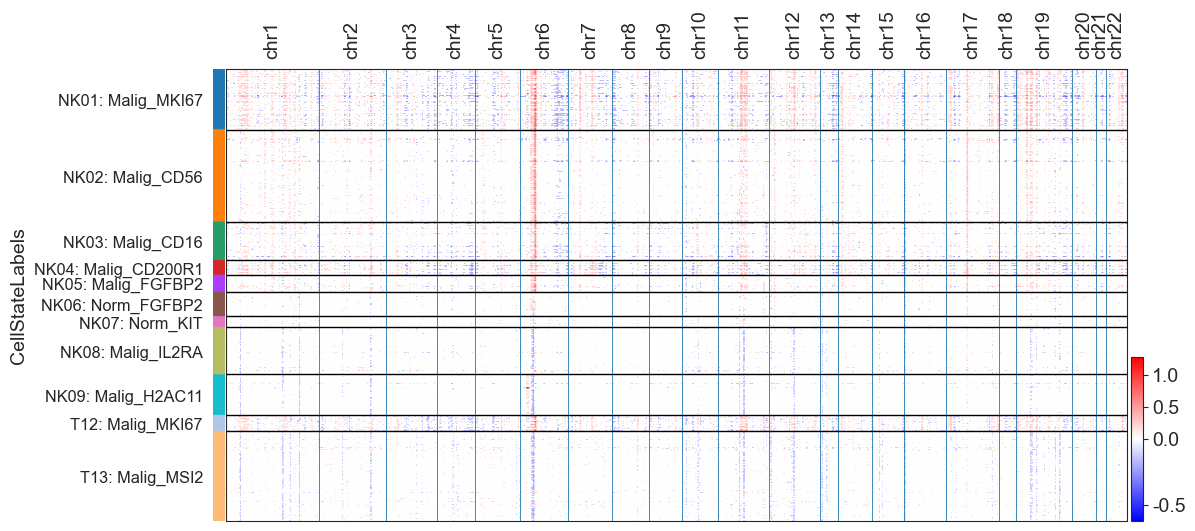

In [963]:
adata_concat_cnv1 = merge(adata_concat_cnv, adata_Tprol, 'CellStateLabels', 'Tprol_status')
ax = cnv.pl.chromosome_heatmap(adata_concat_cnv1[~adata_concat_cnv1.obs['CellStateLabels'].isin(['T12: Tprol_MKI67', 'Mast cells'])], groupby='CellStateLabels',show = False)
fig = ax['heatmap_ax'].get_figure()
fig.set_size_inches(12, 6)
fig.savefig(f"{figPath}/FigS7e.pdf", bbox_inches='tight')
plt.show()